<a href="https://colab.research.google.com/github/ruksar16/product-profitability-margin-analysis/blob/main/Product_Profitability_Analysis_Nassau_Candy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Product Line Profitability & Margin Performance Analysis
## Nassau Candy Distributor

### Objective:
This project analyzes product-level profitability, margin performance, and cost structure to identify high-profit products, low-margin risks, and division-wise financial efficiency.

In [ ]:
# Core libraries

import pandas as pd
import numpy as np

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Reading File

df = pd.read_csv("Nassau Candy Distributor.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

The dataset has **10,194** **rows** and **18 columns** with no missing values. Most columns are categorical (object type), while numeric fields include Sales, Cost, Gross Profit, and Units. The Order Date and Ship Date columns are stored as object type and should be converted to datetime for time-based analysis.

In [ ]:
# Numeric columns and Categorial columns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numeric Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numeric Columns: Index(['Row ID', 'Customer ID', 'Sales', 'Units', 'Gross Profit', 'Cost'], dtype='object')
Categorical Columns: Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Country/Region',
       'City', 'State/Province', 'Postal Code', 'Division', 'Region',
       'Product ID', 'Product Name'],
      dtype='object')


## **Data Cleaning & Validation**

In [ ]:
# Convert categorial to numeric

df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df['Cost'] = pd.to_numeric(df['Cost'], errors='coerce')

# Remove null values

df = df.dropna(subset=['Sales', 'Cost'])

# Remove negative values

df = df[(df['Sales'] >= 0) & (df['Cost'] >= 0)]

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Country/Region,0
City,0
State/Province,0
Postal Code,0


There are **no null or missing values** across any field, so the data is reliable and ready for analysis without any preprocessing or imputation.

In [ ]:
# Create Profit Column

df['Profit'] = df['Sales'] - df['Cost']
# Calculate Gross Margin % at the transaction level
df['Gross_Margin_%'] = ((df['Sales'] - df['Cost']) / df['Sales']) * 100

In [ ]:
# Remove invalid profit (NaN)

df = df[df['Profit'].notna()]
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Profit,Gross_Margin_%
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,4.22,64.923077
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,4.90,65.333333
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,7.47,71.346705
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,7.50,69.444444
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,7.35,65.333333
5,6,US-2021-167199-CHO-SCR-58000,06-01-2024,03-07-2026,Standard Class,167199,United States,Henderson,Kentucky,42420,Chocolate,Gulf,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,32.40,9,22.50,9.90,22.50,69.444444
6,7,US-2021-167199-CHO-TRI-54000,06-01-2024,03-07-2026,Standard Class,167199,United States,Henderson,Kentucky,42420,Chocolate,Gulf,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,4.90,65.333333
7,8,US-2021-106054-CHO-MIL-31000,06-01-2024,30-06-2026,First Class,106054,United States,Athens,Georgia,30605,Chocolate,Gulf,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42,6.33,64.923077
8,9,US-2021-167199-CHO-NUT-13000,06-01-2024,03-07-2026,Standard Class,167199,United States,Henderson,Kentucky,42420,Chocolate,Gulf,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,6.98,2,4.98,2.00,4.98,71.346705
9,10,US-2021-167199-CHO-MIL-31000,06-01-2024,03-07-2026,Standard Class,167199,United States,Henderson,Kentucky,42420,Chocolate,Gulf,CHO-MIL-31000,Wonka Bar - Milk Chocolate,13.00,4,8.44,4.56,8.44,64.923077


In [ ]:
# Checking Duplicates

df.duplicated().sum()

np.int64(0)

The dataset contains **0 duplicate records**, indicating that all entries are unique and there are no repeated rows. This ensures data consistency and reliability for analysis.

In [ ]:
# Unique Products and Divisions

print(df['Product Name'].unique())
print(df['Division'].unique())

['Wonka Bar - Milk Chocolate' 'Wonka Bar - Triple Dazzle Caramel'
 'Wonka Bar - Nutty Crunch Surprise' 'Wonka Bar -Scrumdiddlyumptious'
 'Wonka Bar - Fudge Mallows' 'Wonka Gum' 'Kazookles' 'Lickable Wallpaper'
 'Fizzy Lifting Drinks' 'Laffy Taffy' 'SweeTARTS' 'Nerds' 'Hair Toffee'
 'Everlasting Gobstopper' 'Fun Dip']
['Chocolate' 'Other' 'Sugar']


In [ ]:
# Standardize text columns

df['Product Name'] = df['Product Name'].str.strip().str.lower()
df['Division'] = df['Division'].str.strip().str.lower()

In [ ]:
# Convert into date format

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True, errors='coerce')

In [ ]:
df[num_cols].describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


The dataset shows moderate average **sales** **(13.9)** and low average **units** **(3.79)** per order, indicating small-sized transactions. However, the presence of high maximum values (e.g., **Sales up to 260)** suggests some outliers and right-skewed distribution in the data. Overall, most transactions are low to mid value with a **few high-value orders** influencing the averages.

Most transactions are small and consistent, but a few large orders significantly affect overall distribution and averages.

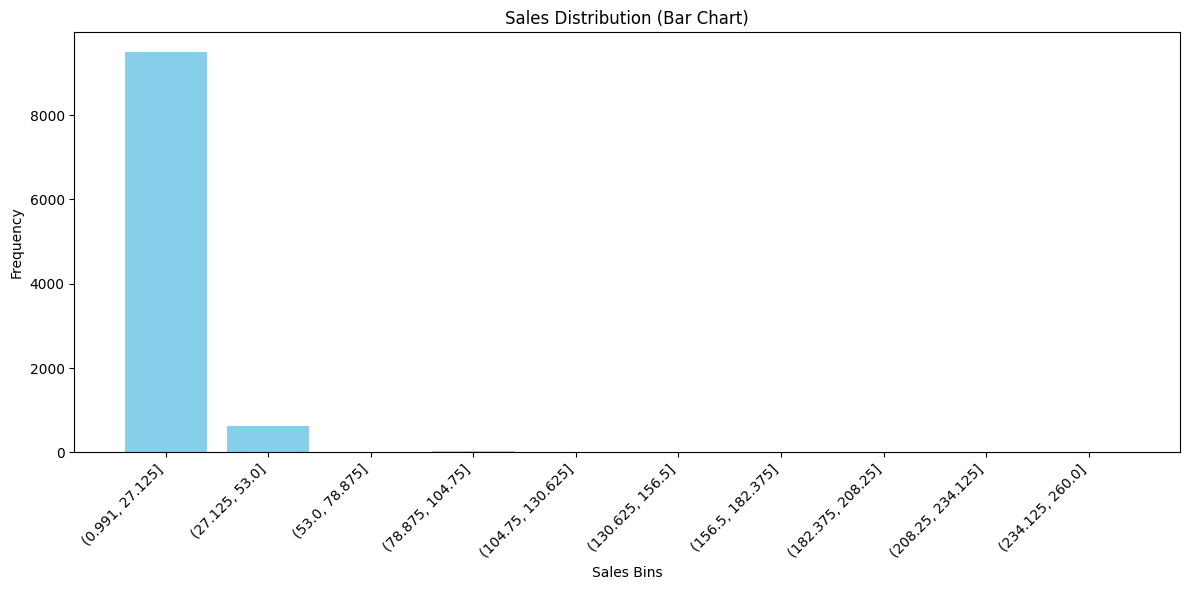

In [ ]:
# Sales Distribution

sales_bins = pd.cut(df['Sales'], bins=10)
sales_count = sales_bins.value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(sales_count.index.astype(str), sales_count.values, color='skyblue')
plt.title('Sales Distribution (Bar Chart)')
plt.xlabel('Sales Bins')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The sales distribution is **right-skewed**, meaning most transactions have **low sales values**, while a few high-value transactions contribute significantly to overall sales.

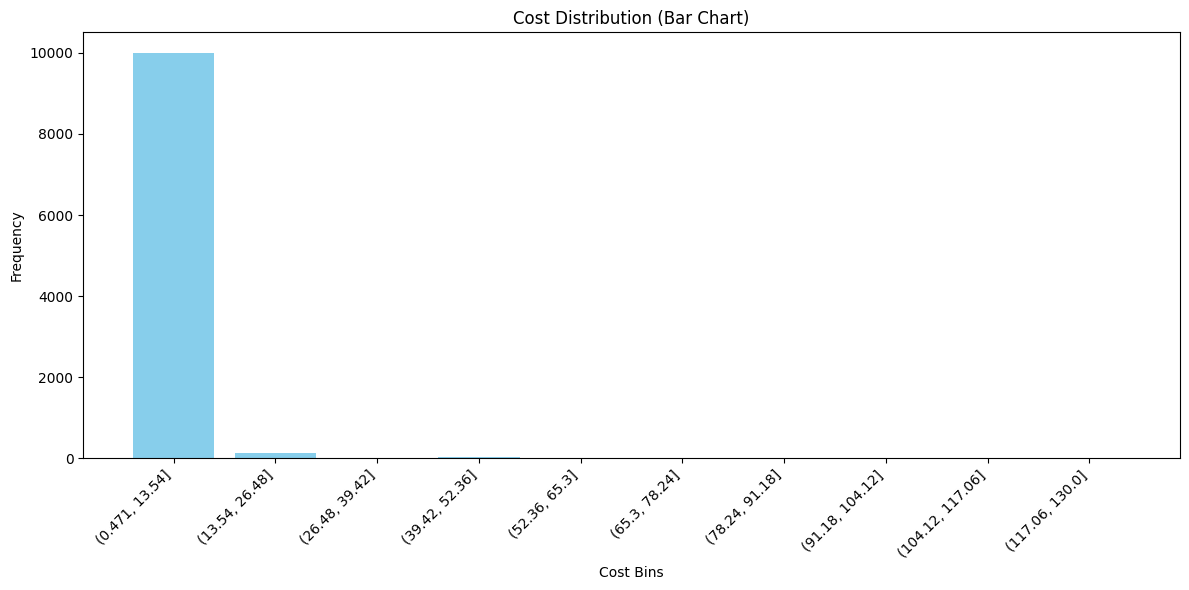

In [ ]:
cost_bins = pd.cut(df['Cost'], bins=10)
cost_count = cost_bins.value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(cost_count.index.astype(str), cost_count.values, color='skyblue')
plt.title('Cost Distribution (Bar Chart)')
plt.xlabel('Cost Bins')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Most of the cost values are concentrated in the **lower range (around 0–10)**, showing that majority of transactions are **low-cost**. The distribution is highly right-skewed, meaning a few very high-cost values exist as outliers.

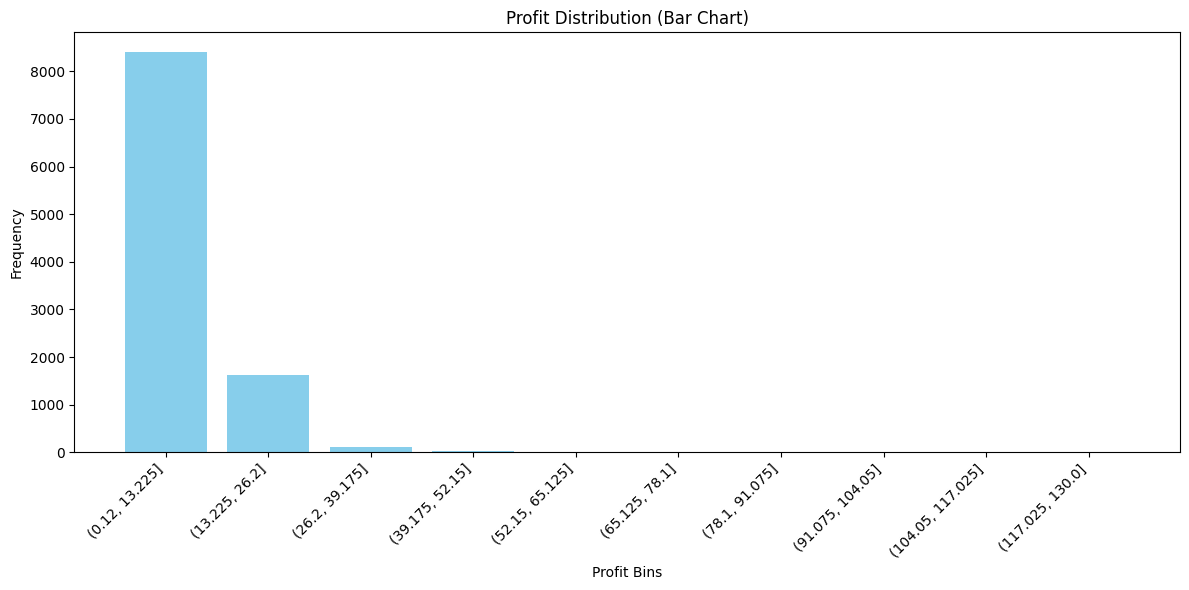

In [ ]:
profit_bins = pd.cut(df['Profit'], bins=10)
profit_count = profit_bins.value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(profit_count.index.astype(str), profit_count.values, color='skyblue')
plt.title('Profit Distribution (Bar Chart)')
plt.xlabel('Profit Bins')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The profit distribution is **highly right-skewed**, meaning most of the values are concentrated in the **lower profit range**. Only a few transactions/products generate very high profits, creating a long tail on the right side. This indicates that a **small number of items are driving most of the higher profitability**.

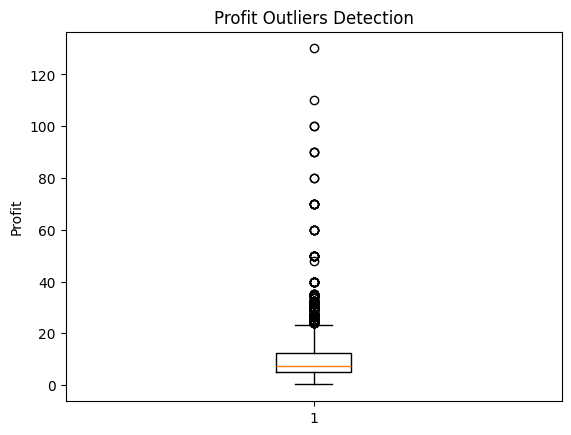

In [ ]:
# Profit Outliers Detection

plt.figure()
plt.boxplot(df['Profit'])
plt.title("Profit Outliers Detection")
plt.ylabel("Profit")
plt.show()

This boxplot shows that most of the **profit values are concentrated in the lower range** (around the median, which is quite small). However, there are many high-value outliers above the upper whisker, indicating a few transactions/products generating unusually high profit.

Overall, the distribution is strongly right-skewed, meaning most items have low to moderate profit while only **a small number contribute very high profits**.

## **Profitability Metric Calculation**

In [ ]:
# Function to calculate Gross Margin

def add_margin(df):
    df['Gross_Margin_%'] = ((df['Sales'] - df['Cost']) / df['Sales']) * 100
    return df

In [ ]:
product_profit = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Cost': 'sum',
    'Profit': 'sum',
    'Units': 'sum'
}).reset_index()

product_profit = add_margin(product_profit)

In [ ]:
# Gross Margin(%) for each product

product_profit[['Product Name', 'Gross_Margin_%']].sort_values(by='Gross_Margin_%', ascending=False).round(2)

,Product Name,Gross_Margin_%
0,everlasting gobstopper,80.00
3,hair toffee,77.78
11,wonka bar - nutty crunch surprise,71.35
13,wonka bar -scrumdiddlyumptious,69.44
9,wonka bar - fudge mallows,66.67
12,wonka bar - triple dazzle caramel,65.33
10,wonka bar - milk chocolate,64.92
5,laffy taffy,62.31
1,fizzy lifting drinks,60.00
14,wonka gum,52.00



Most products show strong gross margins **(45%–80%)**, indicating healthy pricing and good profitability. **Everlasting Gobstopper (80%)** and **Hair Toffee (77.78%)** are top performers. However, **Kazookles (7.69%)** is a clear weak point, pulling efficiency down and needs pricing or cost review. Overall, the product portfolio is highly profitable with few outliers needing optimization.




In [ ]:
# Profit per unit for each product

product_profit['Profit_per_Unit'] = product_profit['Profit'] / product_profit['Units']
product_profit[['Product Name', 'Profit', 'Units', 'Profit_per_Unit']].round(2)

,Product Name,Profit,Units,Profit_per_Unit
0,everlasting gobstopper,104.00,13,8.00
1,fizzy lifting drinks,47.25,21,2.25
2,fun dip,4.80,8,0.60
3,hair toffee,59.50,17,3.50
4,kazookles,92.75,371,0.25
5,laffy taffy,33.48,27,1.24
6,lickable wallpaper,3930.00,393,10.00
7,nerds,7.00,10,0.70
8,sweetarts,28.70,41,0.70
9,wonka bar - fudge mallows,16593.60,6914,2.40


Profit is **highly concentrated in a few products**, mainly **Wonka Bar** variants and **Lickable Wallpaper**, which drive most of the earnings with strong unit profitability. Several products like **Fun Dip, Nerds, and Kazookles** show very low profit per unit, indicating weak efficiency despite sales. Overall, the portfolio is **top-heavy and depends on a** **few high-performing products**, while low-profit items need optimization.

In [ ]:
# Total profit contribution for each product

total_profit = product_profit['Profit'].sum()

product_profit['Profit_Contribution_%'] = (
    product_profit['Profit'] / total_profit
) * 100

product_profit.sort_values(by='Profit_Contribution_%', ascending=False).round(2)

,Product Name,Sales,Cost,Profit,Units,Gross_Margin_%,Profit_per_Unit,Profit_Contribution_%
13,wonka bar -scrumdiddlyumptious,27874.80,8517.30,19357.50,7743,69.44,2.50,20.72
12,wonka bar - triple dazzle caramel,28485.00,9874.80,18610.20,7596,65.33,2.45,19.92
10,wonka bar - milk chocolate,26867.75,9424.38,17443.37,8267,64.92,2.11,18.67
11,wonka bar - nutty crunch surprise,23574.95,6755.00,16819.95,6755,71.35,2.49,18.00
9,wonka bar - fudge mallows,24890.40,8296.80,16593.60,6914,66.67,2.40,17.76
6,lickable wallpaper,7860.00,3930.00,3930.00,393,50.00,10.00,4.21
14,wonka gum,597.50,286.80,310.70,478,52.00,0.65,0.33
0,everlasting gobstopper,130.00,26.00,104.00,13,80.00,8.00,0.11
4,kazookles,1205.75,1113.00,92.75,371,7.69,0.25,0.10
3,hair toffee,76.50,17.00,59.50,17,77.78,3.50,0.06


Profit is **heavily concentrated in top 5 Wonka Bar variants**, which contribute ~95%+ of total profit, making them the core revenue drivers. **Lickable Wallpaper** adds moderate contribution with high efficiency per unit, while all remaining products contribute negligibly **(<1% each)**. Overall, the **business is highly dependent on a small set of high-performing products,** indicating a strong need for diversification or optimization of low-contribution items.

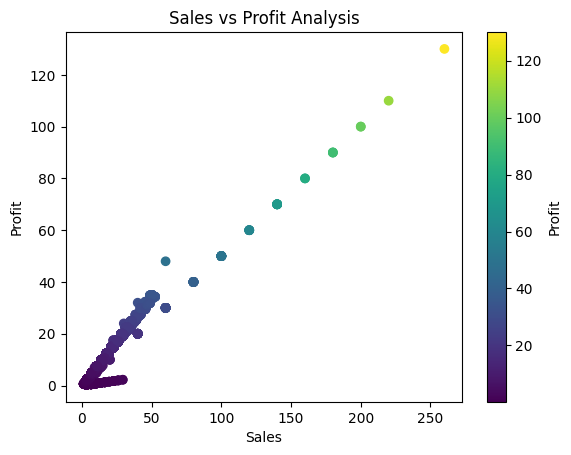

In [ ]:
# Sales vs Profit Analysis

plt.figure()
plt.scatter(df['Sales'], df['Profit'], c=df['Profit'], cmap='viridis')
plt.colorbar(label='Profit')

plt.title("Sales vs Profit Analysis")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

This scatter plot shows a strong positive relationship between sales and profit, meaning as **sales increase, profit also increases** almost proportionally. Most of the data points are clustered in the lower sales range with low profit values.

At higher sales values, profit rises significantly, indicating **better efficiency or scaling benefits in high-performing products**.

In [ ]:
top_margin = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Cost': 'sum'
}).reset_index()

top_margin = add_margin(top_margin)

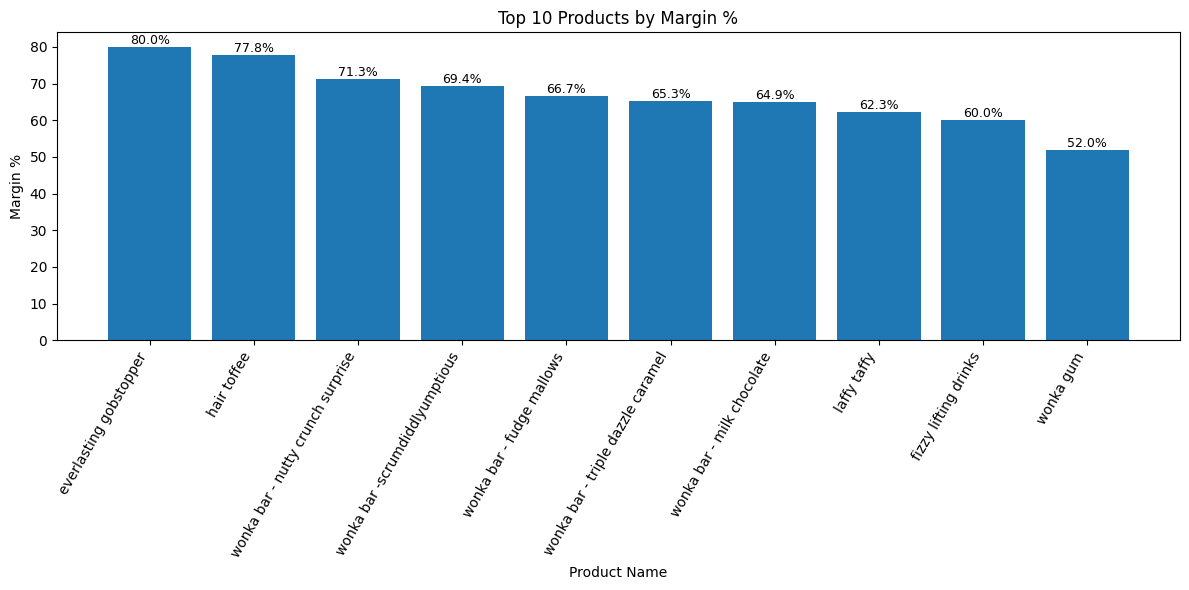

In [ ]:
# Top 10 Products based on Margin

top_margin = top_margin.sort_values(by='Gross_Margin_%', ascending=False).head(10)
plt.figure(figsize=(12,6))
bars = plt.bar(top_margin['Product Name'], top_margin['Gross_Margin_%'])

plt.xticks(rotation=60, ha='right')
plt.title("Top 10 Products by Margin %")
plt.xlabel("Product Name")
plt.ylabel("Margin %")

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

Most profitable products are **Everlasting Gobstopper (~80%)** and **Hair Toffee (~77.8%)**.
Majority of products maintain 60–70% margin, showing strong overall profitability.
Overall, margins are strong but uneven across products.

## **Product-Level Profitability Analysis**

In [ ]:
# Ranking products by Gross Profit

product_profit['Profit_Rank'] = product_profit['Profit'].rank(ascending=False)

product_profit[['Product Name', 'Profit', 'Profit_Rank']].sort_values(by='Profit_Rank').round(2)

,Product Name,Profit,Profit_Rank
13,wonka bar -scrumdiddlyumptious,19357.50,1.0
12,wonka bar - triple dazzle caramel,18610.20,2.0
10,wonka bar - milk chocolate,17443.37,3.0
11,wonka bar - nutty crunch surprise,16819.95,4.0
9,wonka bar - fudge mallows,16593.60,5.0
6,lickable wallpaper,3930.00,6.0
14,wonka gum,310.70,7.0
0,everlasting gobstopper,104.00,8.0
4,kazookles,92.75,9.0
3,hair toffee,59.50,10.0


   Profit is **highly concentrated in top 5 Wonka Bar products**, which dominate overall earnings. Lickable Wallpaper is the only mid-level contributor, while all other products have very low profit and minimal impact, showing strong dependency on a few key products.

In [ ]:
# Ranking products by Gross Margin

product_profit['Margin_Rank'] = product_profit['Gross_Margin_%'].rank(ascending=False)

product_profit[['Product Name', 'Gross_Margin_%', 'Margin_Rank']].sort_values(by='Margin_Rank').round(2)

,Product Name,Gross_Margin_%,Margin_Rank
0,everlasting gobstopper,80.00,1.0
3,hair toffee,77.78,2.0
11,wonka bar - nutty crunch surprise,71.35,3.0
13,wonka bar -scrumdiddlyumptious,69.44,4.0
9,wonka bar - fudge mallows,66.67,5.0
12,wonka bar - triple dazzle caramel,65.33,6.0
10,wonka bar - milk chocolate,64.92,7.0
5,laffy taffy,62.31,8.0
1,fizzy lifting drinks,60.00,9.0
14,wonka gum,52.00,10.0


**Everlasting Gobstopper** and **Hair Toffee** lead with the **highest margins**, while **Wonka Bar** variants consistently perform strong. Mid-tier products are stable but have some improvement potential. **Kazookles is the weakest** with a very low margin, requiring urgent attention.

In [ ]:
# Calculating median of Sales, Profit, and Margin

sales_median = product_profit['Sales'].median()
profit_median = product_profit['Profit'].median()
margin_median = product_profit['Gross_Margin_%'].median()

In [ ]:
# High-profit / high-margin products

print('High Profit / High Margin Products\n')
high_profit_high_margin = product_profit[
    (product_profit['Profit'] >= profit_median) &
    (product_profit['Gross_Margin_%'] >= margin_median)
]

high_profit_high_margin[['Product Name', 'Profit', 'Gross_Margin_%']].round(2)

High Profit / High Margin Products



,Product Name,Profit,Gross_Margin_%
0,everlasting gobstopper,104.00,80.00
9,wonka bar - fudge mallows,16593.60,66.67
10,wonka bar - milk chocolate,17443.37,64.92
11,wonka bar - nutty crunch surprise,16819.95,71.35
12,wonka bar - triple dazzle caramel,18610.20,65.33
13,wonka bar -scrumdiddlyumptious,19357.50,69.44


**Wonka Bar variants are the main profit drivers**, with Scrumdiddlyumptious and **Triple Dazzle** Caramel leading. **Nutty Crunch** Surprise balances both high profit and strong margin. **Everlasting Gobstopper** has the highest margin but very low profit, indicating low sales volume.

In [ ]:
# High Sales / Low Margin Products

print(' High-sales / low-margin products\n')
high_sales_low_margin = product_profit[
    (product_profit['Sales'] >= sales_median) &
    (product_profit['Gross_Margin_%'] < margin_median)
]

high_sales_low_margin[['Product Name', 'Sales', 'Gross_Margin_%']].round(2)

 High-sales / low-margin products



,Product Name,Sales,Gross_Margin_%
4,kazookles,1205.75,7.69
6,lickable wallpaper,7860.00,50.00
14,wonka gum,597.50,52.00


**Kazookles generates relatively higher sales** among the three but has an extremely low margin **(~7.7%)**, making it inefficient. **Lickable Wallpaper** shows a balanced performance with decent sales and a moderate **50%** margin. **Wonka Gum** has a slightly better margin **(~52%)** but very low sales, indicating limited market demand.

In [ ]:
# Low Sales / Low Profit Products

print('Low-sales / low-profit products\n')
low_sales_low_profit = product_profit[
    (product_profit['Sales'] < sales_median) &
    (product_profit['Profit'] < profit_median)
]

low_sales_low_profit[['Product Name', 'Sales', 'Profit']].round(2)

Low-sales / low-profit products



,Product Name,Sales,Profit
1,fizzy lifting drinks,78.75,47.25
2,fun dip,12.00,4.80
3,hair toffee,76.50,59.50
5,laffy taffy,53.73,33.48
7,nerds,15.00,7.00
8,sweetarts,61.50,28.70


**Hair Toffee** stands out with strong profit relative to its sales, indicating high efficiency. **Laffy Taffy** and **SweeTARTS** show balanced performance with moderate sales and profits. **Fizzy Lifting Drinks** has decent profitability despite low sales, while **Nerds** and **Fun Dip** contribute minimal sales and profit, making them low-impact products.

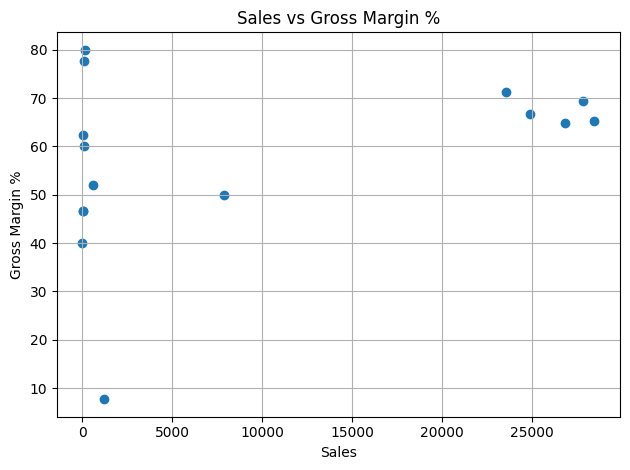

In [ ]:
# Sales vs Gross Margin

plt.scatter(product_profit['Sales'], product_profit['Gross_Margin_%'])

plt.title("Sales vs Gross Margin %")
plt.xlabel("Sales")
plt.ylabel("Gross Margin %")

plt.grid(True)

plt.tight_layout()
plt.show()

Sales and Gross Margin % show no **clear direct correlation**.
**High sales products** mostly maintain stable margins around **65–70%**.
Low sales items have wide margin variation, from very low to very high.
Overall, profitability depends more on product type than sales volume.

## **Division-Level Performance Analysis**


In [ ]:
# Group by Division

division_perf = df.groupby('Division').agg({
    'Sales': 'sum',
    'Cost': 'sum',
    'Profit': 'sum'
}).reset_index()

division_perf = add_margin(division_perf)

print("\nAggregated Division Metrics:\n")
division_perf.round(2)


Aggregated Division Metrics:



,Division,Sales,Cost,Profit,Gross_Margin_%
0,chocolate,131692.90,42868.28,88824.62,67.45
1,other,9663.25,5329.80,4333.45,44.84
2,sugar,427.48,142.75,284.73,66.61


**Chocolate division** dominates with the **highest sales and profit**, making it the primary revenue driver.
**Other division shows moderate performance** with stable but limited contribution.
**Sugar division has very low sales and profit**, indicating weak performance.
Overall, business is highly dependent on chocolate, with scope to improve other divisions.

In [ ]:
# Average Margin by Division

avg_margin = division_perf[['Division', 'Gross_Margin_%']] \
                .sort_values(by='Gross_Margin_%', ascending=False)

print("\nAverage Margin by Division:\n")
avg_margin.round(2)


Average Margin by Division:



,Division,Gross_Margin_%
0,chocolate,67.45
2,sugar,66.61
1,other,44.84


**Chocolate and sugar divisions** have very high and almost similar margins **(~67%)**, indicating strong profitability.
**Other division** has a significantly **lower margin (~45%)**, showing weaker cost efficiency.
**Despite sugar’s high margin**, its overall impact is low due to very small sales volume.
Overall, profitability is strong, but efficiency varies across divisions, especially in “other.”

In [ ]:
# Revenue vs Profit Imbalance

division_perf['Profit_Ratio'] = division_perf['Profit'] / division_perf['Sales']

division_perf['Revenue_Profit_Imbalance'] = np.where(
    (division_perf['Sales'] > division_perf['Sales'].mean()) &
    (division_perf['Profit_Ratio'] < division_perf['Profit_Ratio'].mean()),
    'High Revenue Low Profit',
    'Normal'
)

print("\nRevenue vs Profit Imbalance:\n")
division_perf[['Division', 'Sales', 'Profit', 'Revenue_Profit_Imbalance']]



Revenue vs Profit Imbalance:



,Division,Sales,Profit,Revenue_Profit_Imbalance
0,chocolate,131692.90,88824.62,Normal
1,other,9663.25,4333.45,Normal
2,sugar,427.48,284.73,Normal


The **chocolate division** generates the **highest revenue and profit**, it is the main growth driver.
The **other** and **sugar divisions** contribute relatively **low revenue and profit**.

**Conclusion:**
The business is **financially stable** overall. Focus on expanding the chocolate division while improving performance in the smaller divisions.

In [ ]:
#  Strong financial efficiency

division_perf['Strong_Efficiency'] = np.where(
    division_perf['Gross_Margin_%'] > division_perf['Gross_Margin_%'].mean(),
    'Efficient',
    'Not Efficient'
)

print("\nStrong Financial Efficiency:\n")
division_perf[['Division', 'Gross_Margin_%', 'Strong_Efficiency']].round(2)



Strong Financial Efficiency:



,Division,Gross_Margin_%,Strong_Efficiency
0,chocolate,67.45,Efficient
1,other,44.84,Not Efficient
2,sugar,66.61,Efficient


**Chocolate** and **sugar divisions** have **high margins (~66–67%)**, indicating strong cost efficiency and profitability.
The **other division** has a significantly **lower margin (44.84%)**, showing weaker cost control or pricing inefficiencies.

**Conclusion:**
Overall efficiency is strong, driven by chocolate and sugar. The **other division needs optimization** (cost reduction or pricing improvement) to match overall performance.

In [ ]:
# Structural margin issues

division_perf['Cost_Ratio'] = division_perf['Cost'] / division_perf['Sales']

division_perf['Structural_Issue'] = np.where(
    (division_perf['Gross_Margin_%'] < division_perf['Gross_Margin_%'].mean()) &
    (division_perf['Cost_Ratio'] > division_perf['Cost_Ratio'].mean()),
    'Issue',
    'Stable'
)

print("\nStructural Margin Issues:\n")
division_perf[['Division', 'Gross_Margin_%', 'Cost_Ratio', 'Structural_Issue']].round(2)



Structural Margin Issues:



,Division,Gross_Margin_%,Cost_Ratio,Structural_Issue
0,chocolate,67.45,0.33,Stable
1,other,44.84,0.55,Issue
2,sugar,66.61,0.33,Stable


**Chocolate** and **sugar divisions** have **low cost ratios (~0.33)** and **high margins**that is structurally stable and efficient.
The **other division** has a **high cost ratio (0.55)** and **lower margin** that is clear structural issue (higher costs eating into profit).

**Conclusion:**
Core business (chocolate & sugar) is strong and stable. The **other division requires restructuring**, such as cost reduction, better pricing, or process optimization to improve margins.

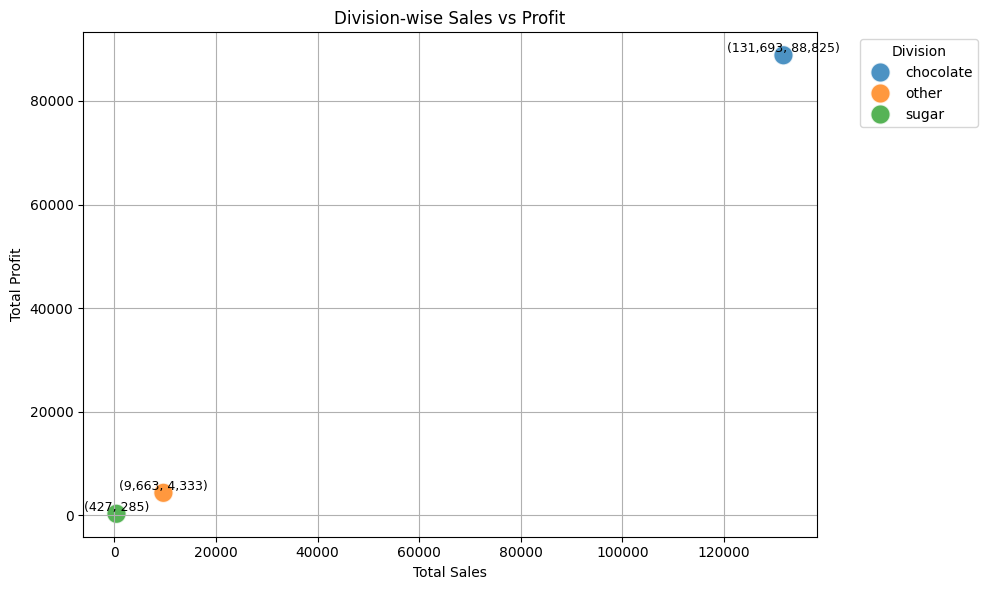

In [ ]:
# Division wise Sales vs Profit

division_profit = df.groupby('Division').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=division_profit,
    x='Sales',
    y='Profit',
    hue='Division',
    s=200,
    alpha=0.8
)

for i in range(division_profit.shape[0]):
    plt.text(
        division_profit['Sales'][i],
        division_profit['Profit'][i],
        f"({division_profit['Sales'][i]:,.0f}, {division_profit['Profit'][i]:,.0f})",
        fontsize=9,
        ha='center',
        va='bottom'
    )

plt.title("Division-wise Sales vs Profit")
plt.xlabel("Total Sales")
plt.ylabel("Total Profit")
plt.grid(True)

plt.legend(title="Division", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

The 'Division-wise Sales vs Profit' scatterplot clearly shows that the **Chocolate division is the primary driver of both sales and profit**, demonstrating superior performance. The **'Other' division** contributes moderately to both sales and profit. In contrast, the **'Sugar' division** has the lowest sales and profit, indicating minimal overall contribution. This analysis highlights the business's heavy reliance on the Chocolate division, suggesting opportunities to enhance the performance of the 'Other' and 'Sugar' divisions for a more balanced portfolio.

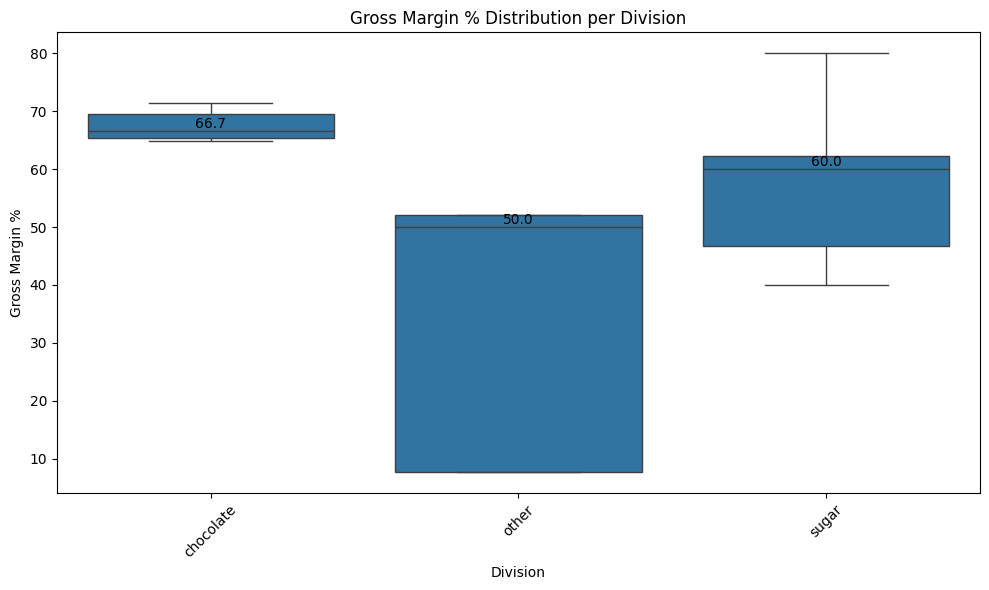

In [ ]:
# Gross Margin Distribution per Division

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Division',
    y='Gross_Margin_%'
)

for i, div in enumerate(df['Division'].unique()):
    median = df[df['Division']==div]['Gross_Margin_%'].median()
    plt.text(i, median, f"{median:.1f}", ha='center', va='bottom')

plt.title('Gross Margin % Distribution per Division')
plt.xlabel('Division')
plt.ylabel('Gross Margin %')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

The **Chocolate division** shows the highest and most stable gross margin **(~66–71%)**, indicating consistent profitability.
The **Sugar divisio**n has a moderately high median **(~60%)** but shows wider variation, meaning performance is less stable than Chocolate.
The **Other division** has the lowest and most volatile margins, with a very wide spread **(around 8% to 50%)**, indicating inconsistent or mixed product performance.
Overall, Chocolate is the most efficient and reliable division in terms of profitability.

## **Profit Concentration (Pareto) Analysis**

In [ ]:
product_df = product_profit.copy()

In [ ]:
# Revenue Pareto

product_df = product_df.sort_values(by='Sales', ascending=False)
product_df['Revenue_%'] = product_df['Sales'] / product_df['Sales'].sum() * 100
product_df['Cum_Revenue_%'] = product_df['Revenue_%'].cumsum()

# Products contributing to 80% revenue
top_rev_products = product_df[product_df['Cum_Revenue_%'] <= 80]

print("\nProducts contributing to 80% Revenue:\n")
top_rev_products[['Product Name', 'Sales', 'Cum_Revenue_%']].round(2)


Products contributing to 80% Revenue:



,Product Name,Sales,Cum_Revenue_%
12,wonka bar - triple dazzle caramel,28485.00,20.09
13,wonka bar -scrumdiddlyumptious,27874.80,39.75
10,wonka bar - milk chocolate,26867.75,58.70
9,wonka bar - fudge mallows,24890.40,76.26


A small group of products is driving the majority of revenue, indicating a strong Pareto effect.

The top **4 products alone contribute ~76% of total revenue**, showing high revenue concentration.
**“Triple Dazzle Caramel” and “Scrumdiddlyumptious”** are the biggest drivers, together contributing nearly **40%**.
This suggests **dependency risk**—if demand for these key products drops, overall revenue will be heavily impacted.
The remaining products contribute relatively little, indicating a **long tail with low revenue efficiency**.

In [ ]:
# Profit Pareto

product_df = product_df.sort_values(by='Profit', ascending=False)
product_df['Profit_%'] = product_df['Profit'] / product_df['Profit'].sum() * 100
product_df['Cum_Profit_%'] = product_df['Profit_%'].cumsum()

# Products contributing to 80% profit
top_profit_products = product_df[product_df['Cum_Profit_%'] <= 80]

print("\nProducts contributing to 80% Profit:")
top_profit_products[['Product Name', 'Profit', 'Cum_Profit_%']].round(2)


Products contributing to 80% Profit:


,Product Name,Profit,Cum_Profit_%
13,wonka bar -scrumdiddlyumptious,19357.50,20.72
12,wonka bar - triple dazzle caramel,18610.20,40.63
10,wonka bar - milk chocolate,17443.37,59.30
11,wonka bar - nutty crunch surprise,16819.95,77.30


**Top 4 Wonka products** contribute around **77% of total profit**, showing strong concentration
B**usiness is highly dependent on a small number of products** (Pareto effect)
If these products underperform, overall profit will be heavily impacted
There is an opportunity to **improve lower-performing products** to reduce risk

In [ ]:
# Group by Region

region_df = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()


In [ ]:
# Rigion Sort by revenue

region_df = region_df.sort_values(by='Sales', ascending=False)
region_df['Revenue_%'] = region_df['Sales'] / region_df['Sales'].sum() * 100
region_df['Cum_Revenue_%'] = region_df['Revenue_%'].cumsum()

print("\nRegion-wise Contribution:\n")
region_df.round(2)


Region-wise Contribution:



,Region,Sales,Profit,Revenue_%,Cum_Revenue_%
3,Pacific,46301.53,30485.94,32.66,32.66
0,Atlantic,41197.24,26973.70,29.06,61.71
2,Interior,32037.60,21282.49,22.60,84.31
1,Gulf,22247.26,14700.67,15.69,100.00


**Pacific and Atlantic** together contribute about **62% of total revenue**, showing strong regional concentration.
Adding **Interior** takes it to around **84%**, meaning m**ost revenue comes from top 3 regions**
**Gulf contributes the least**, indicating weaker performance compared to others
Business is more reliant on Pacific and Atlantic, so any decline there can significantly affect overall revenue
**Gulf region has potential for** **growth and improvement**

In [ ]:
# Detect over-dependency (if top 1 or 2 regions contribute > 60-70%)

top_regions = region_df.head(2)
dependency = top_regions['Revenue_%'].sum()

print(f"Top 2 Regions Contribution: {dependency:.2f}%")

if dependency > 70:
    print("\nOver-dependency Risk: Few regions dominate revenue")
else:
    print("\nBalanced regional distribution")

Top 2 Regions Contribution: 61.71%

Balanced regional distribution


**Top 2 regions contribute ~62%**, indicating moderate dependency, but overall distribution remains **fairly balanced**

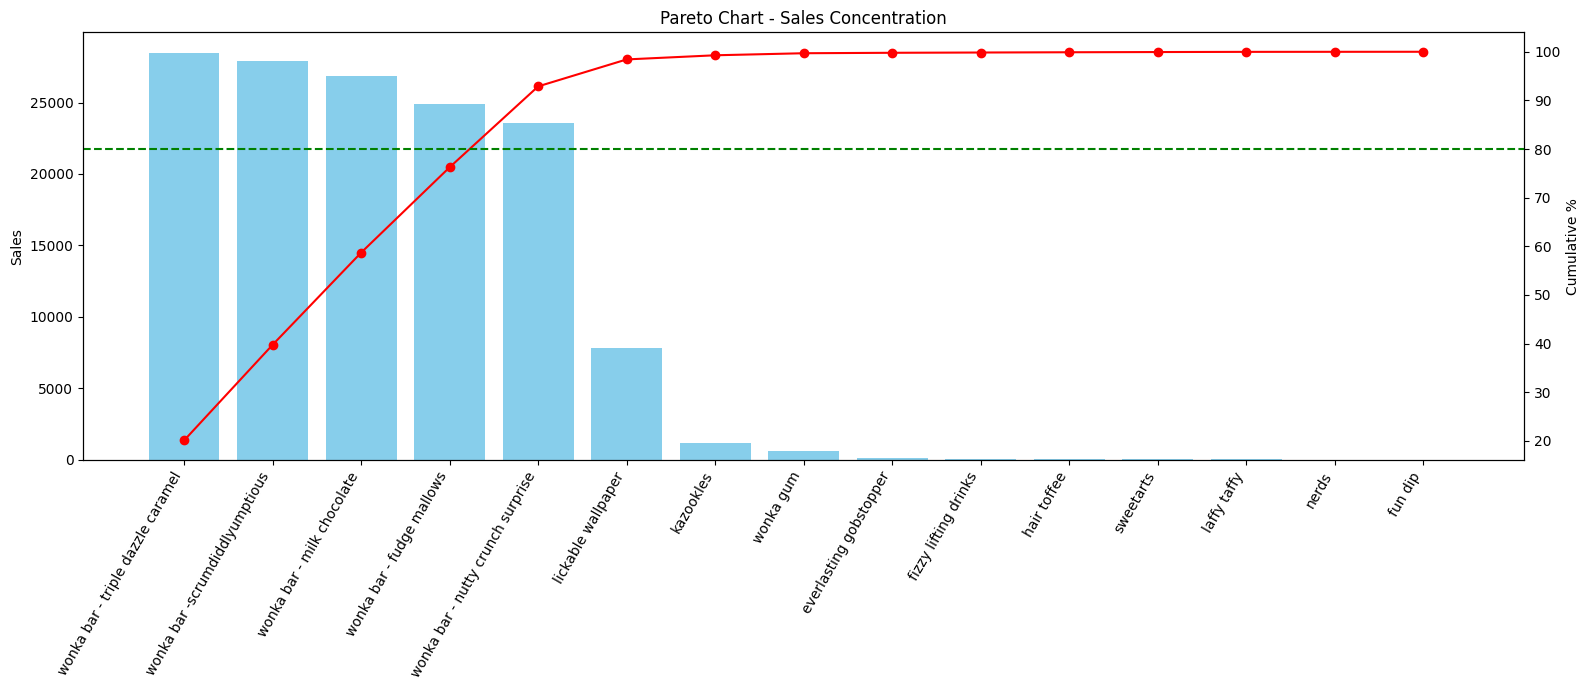

In [ ]:
# Pareto Chart - Sales Concentration

product_pareto = product_profit.copy()

product_pareto = product_pareto.sort_values(by='Sales', ascending=False)

product_pareto['cum_sales'] = product_pareto['Sales'].cumsum()
product_pareto['cum_sales_pct'] = 100 * product_pareto['cum_sales'] / product_pareto['Sales'].sum()

fig, ax1 = plt.subplots(figsize=(16,7))

ax1.bar(product_pareto['Product Name'], product_pareto['Sales'], color='skyblue')
plt.xticks(rotation=60, ha='right')
ax1.set_ylabel('Sales')

ax2 = ax1.twinx()
ax2.plot(product_pareto['Product Name'], product_pareto['cum_sales_pct'], color='red', marker='o')
ax2.set_ylabel('Cumulative %')

ax2.axhline(80, color='green', linestyle='--')

plt.xticks(rotation=90)
plt.title("Pareto Chart - Sales Concentration")
plt.tight_layout()
plt.show()

The Pareto Chart for Sales Concentration highlights that a small number of products are responsible for the majority of sales. Specifically, the **top 4 products contribute \~76% of the total revenue**. This indicates a high concentration of sales, with **'Triple Dazzle Caramel'** and **'Scrumdiddlyumptious'** alone accounting for nearly **40%**. This heavy reliance on a few key products presents a dependency risk, as fluctuations in their demand could significantly impact overall revenue, while many other products contribute very little.

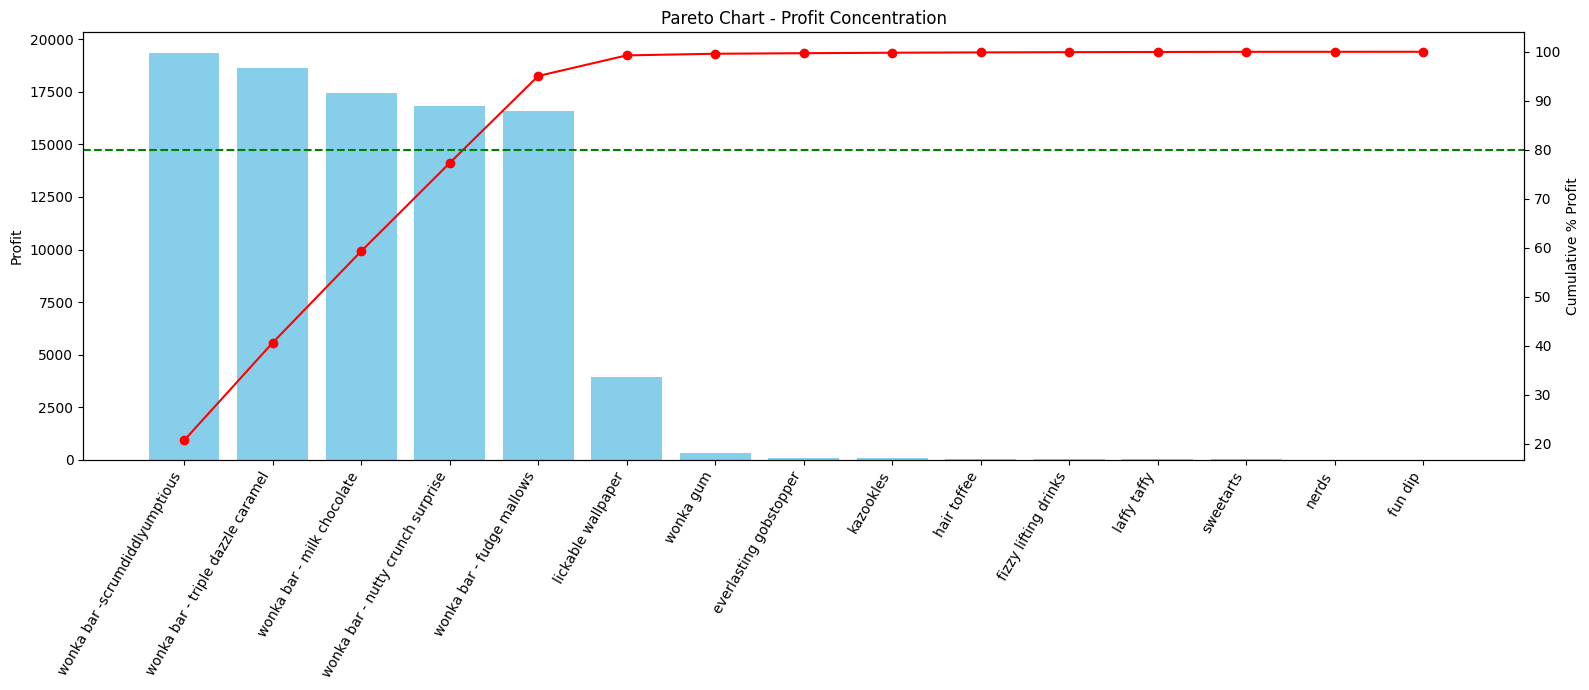

In [ ]:
# Pareto Chart - Profit Concentration

product_pareto = product_pareto.sort_values(by='Profit', ascending=False)

product_pareto['cum_profit'] = product_pareto['Profit'].cumsum()
product_pareto['cum_profit_pct'] = (
    product_pareto['cum_profit'] / product_pareto['Profit'].sum()
) * 100

fig, ax1 = plt.subplots(figsize=(16,7))

ax1.bar(product_pareto['Product Name'], product_pareto['Profit'], color='skyblue')
plt.xticks(rotation=60, ha='right')
ax1.set_ylabel('Profit')

ax2 = ax1.twinx()
ax2.plot(
    product_pareto['Product Name'],
    product_pareto['cum_profit_pct'],
    color='red',
    marker='o'
)
ax2.set_ylabel('Cumulative % Profit')

ax2.axhline(80, color='green', linestyle='--')

plt.title("Pareto Chart - Profit Concentration")
plt.tight_layout()
plt.show()

The Pareto Chart for Profit Concentration shows that the **top 4 Wonka products contribute \~77% of the total profit**. This signifies a high dependency on a small number of products, meaning that the business relies heavily on their performance. There's also an opportunity to improve the lower-performing products to diversify the profit base and reduce risk.

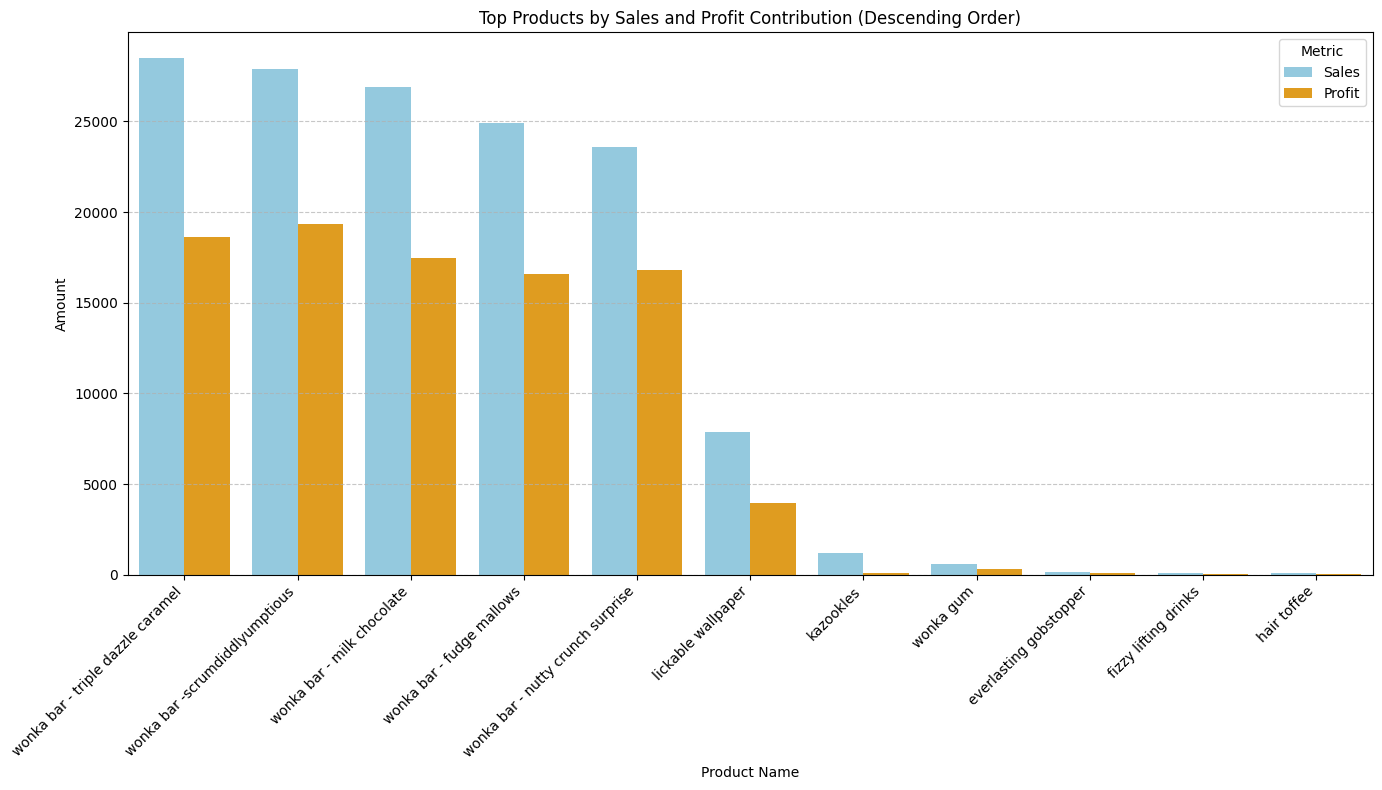

In [ ]:
def add_margin(df):
    df['Gross_Margin_%'] = ((df['Sales'] - df['Cost']) / df['Sales']) * 100
    return df

product_profit = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Cost': 'sum',
    'Profit': 'sum',
    'Units': 'sum'
}).reset_index()

product_profit = add_margin(product_profit)

top_sales_products = product_profit.nlargest(10, 'Sales')
top_profit_products = product_profit.nlargest(10, 'Profit')

# Combine the product names from both lists
all_top_product_names = pd.concat([
    top_sales_products['Product Name'],
    top_profit_products['Product Name']
]).unique()

# Filter the original product_profit DataFrame for these products
top_products_combined = product_profit[
    product_profit['Product Name'].isin(all_top_product_names)
]

# Prepare data for plotting
top_products_melted = top_products_combined.melt(
    id_vars='Product Name',
    value_vars=['Sales', 'Profit'],
    var_name='Metric',
    value_name='Value'
)

# Sort the melted DataFrame by 'Value' in descending order
top_products_melted_sorted = top_products_melted.sort_values(by='Value', ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(
    data=top_products_melted_sorted,
    x='Product Name',
    y='Value',
    hue='Metric',
    palette={'Sales': 'skyblue', 'Profit': 'orange'}
)

plt.xticks(rotation=45, ha='right')
plt.title('Top Products by Sales and Profit Contribution (Descending Order)')
plt.xlabel('Product Name')
plt.ylabel('Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

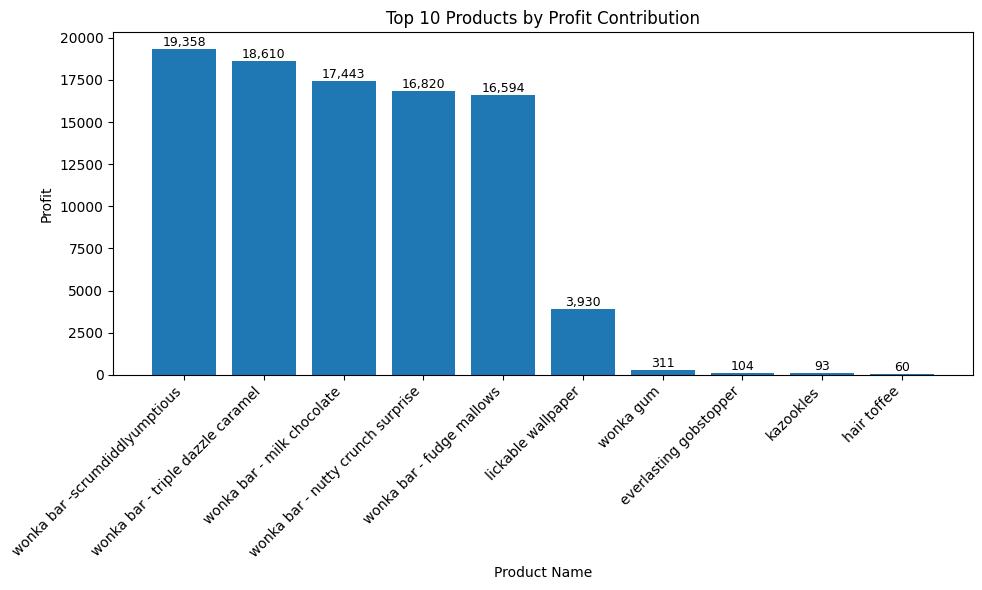

In [ ]:
# Top 10 Products based on Profit Contribution

top_products = (
    product_profit
    .sort_values(by='Profit', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

plt.figure(figsize=(10,6))

bars = plt.bar(top_products['Product Name'].values, top_products['Profit'].values)

plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Products by Profit Contribution")
plt.xlabel("Product Name")
plt.ylabel("Profit")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

Profit is heavily concentrated in the **top 5 Wonka Bar variants**, which collectively account for over **95%** of the total profit, making them the core drivers of earnings. **'Lickable Wallpaper'** also contributes moderately with high efficiency per unit. However, the remaining products contribute negligibly, highlighting a strong dependency on a small set of high-performing items and suggesting a need to diversify or optimize low-contribution products.

## **Cost Structure Diagnostics**

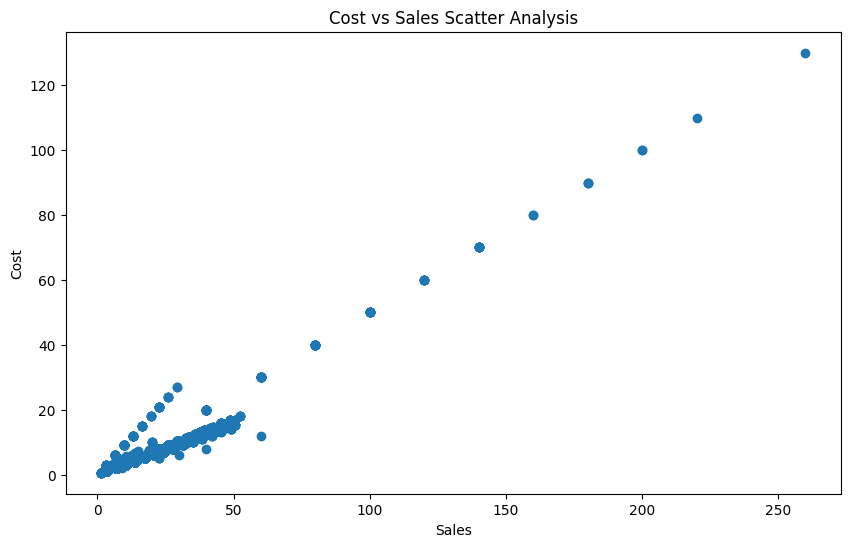

In [ ]:
# Cost vs sales scatter analysis

plt.figure(figsize=(10,6))
plt.scatter(df['Sales'], df['Cost'])

plt.xlabel('Sales')
plt.ylabel('Cost')
plt.title('Cost vs Sales Scatter Analysis')

plt.show()

The scatter plot shows a clear **positive relationship** between sales and cost, indicating that as **sales increase, costs also rise consistently**. Most of the data points are concentrated in the lower sales range **(0–50)**, suggesting that the majority of transactions are small in scale. However, a few high-sales values stand out as outliers, with significantly higher costs compared to the rest. Overall, the pattern appears nearly linear, implying a stable and predictable cost structure as sales grow.

In [ ]:
# Products Representing Margin Risk

print('Products Representing Margin Risk (Below 25th Percentile Gross Margin):')

# Calculate the 25th percentile for Gross_Margin_%
margin_risk_cut = product_profit['Gross_Margin_%'].quantile(0.25)

# Filter products with Gross_Margin_% below the 25th percentile
products_with_margin_risk = product_profit[
    product_profit['Gross_Margin_%'] < margin_risk_cut
].sort_values(by='Gross_Margin_%', ascending=True)

products_with_margin_risk[['Product Name', 'Gross_Margin_%', 'Sales', 'Profit']].round(2)

Products Representing Margin Risk (Below 25th Percentile Gross Margin):


,Product Name,Gross_Margin_%,Sales,Profit
4,kazookles,7.69,1205.75,92.75
2,fun dip,40.00,12.00,4.80
7,nerds,46.67,15.00,7.00
8,sweetarts,46.67,61.50,28.70


In [ ]:
# Repricing Products

print('Products Needing Repricing (Below Median Margin and Profit per Unit):\n')

# Calculate Profit_per_Unit if not already present in product_profit
if 'Profit_per_Unit' not in product_profit.columns:
    product_profit['Profit_per_Unit'] = product_profit['Profit'] / product_profit['Units']

# Calculate median for Gross_Margin_% and Profit_per_Unit
margin_median = product_profit['Gross_Margin_%'].median()
profit_per_unit_median = product_profit['Profit_per_Unit'].median()

# Flag products needing repricing
products_for_repricing = product_profit[
    (product_profit['Gross_Margin_%'] < margin_median) &
    (product_profit['Profit_per_Unit'] < profit_per_unit_median)
]

products_for_repricing[['Product Name', 'Gross_Margin_%', 'Profit_per_Unit']].round(2)

Products Needing Repricing (Below Median Margin and Profit per Unit):



,Product Name,Gross_Margin_%,Profit_per_Unit
2,fun dip,40.00,0.60
4,kazookles,7.69,0.25
7,nerds,46.67,0.70
8,sweetarts,46.67,0.70
14,wonka gum,52.00,0.65


In [ ]:
# Cost Renegotiation

print('Products Needing Cost Renegotiation (High Cost Ratio and Low Gross Margin):\n')

# Calculate Cost_Ratio if not already present in product_profit
product_profit['Cost_Ratio'] = product_profit['Cost'] / product_profit['Sales']

# Calculate median for Cost_Ratio
cost_ratio_median = product_profit['Cost_Ratio'].median()

# Flag products needing cost renegotiation
products_for_cost_renegotiation = product_profit[
    (product_profit['Cost_Ratio'] > cost_ratio_median) &
    (product_profit['Gross_Margin_%'] < margin_median)
]

products_for_cost_renegotiation[['Product Name', 'Sales', 'Cost', 'Cost_Ratio', 'Gross_Margin_%']].round(2)

Products Needing Cost Renegotiation (High Cost Ratio and Low Gross Margin):



,Product Name,Sales,Cost,Cost_Ratio,Gross_Margin_%
1,fizzy lifting drinks,78.75,31.5,0.40,60.00
2,fun dip,12.00,7.2,0.60,40.00
4,kazookles,1205.75,1113.0,0.92,7.69
6,lickable wallpaper,7860.00,3930.0,0.50,50.00
7,nerds,15.00,8.0,0.53,46.67
8,sweetarts,61.50,32.8,0.53,46.67
14,wonka gum,597.50,286.8,0.48,52.00


In [ ]:
# Discontinuing Products

product_discontinue_df = product_df.copy()

# Thresholds
sales_cut = product_discontinue_df['Sales'].quantile(0.25)
profit_cut = product_discontinue_df['Profit'].quantile(0.25)
margin_cut = product_discontinue_df['Gross_Margin_%'].quantile(0.25)

# Discontinue flag
product_discontinue_df['Discontinue'] = np.where(
    (product_discontinue_df['Sales'] <= sales_cut) &
    (product_discontinue_df['Profit'] <= profit_cut) &
    (product_discontinue_df['Gross_Margin_%'] < margin_cut),
    True,
    False
)

discontinue_df = product_discontinue_df[product_discontinue_df['Discontinue'] == True]

discontinue_df = discontinue_df.drop_duplicates(subset=['Product Name'])

result = discontinue_df[['Product Name', 'Sales', 'Cost', 'Profit', 'Gross_Margin_%']]

print("\nDiscontinuing Products:\n")
result.round(2)


Discontinuing Products:



,Product Name,Sales,Cost,Profit,Gross_Margin_%
8,sweetarts,61.5,32.8,28.7,46.67
7,nerds,15.0,8.0,7.0,46.67
2,fun dip,12.0,7.2,4.8,40.00


**Sweetarts**, **Nerds**, and **Fun Dip** show low sales and low profit despite having moderate margins **(~40–46%)**, indicating weak demand rather than pricing issues. These products contribute minimal value overall, making them strong candidates for **discontinuation or replacement**.

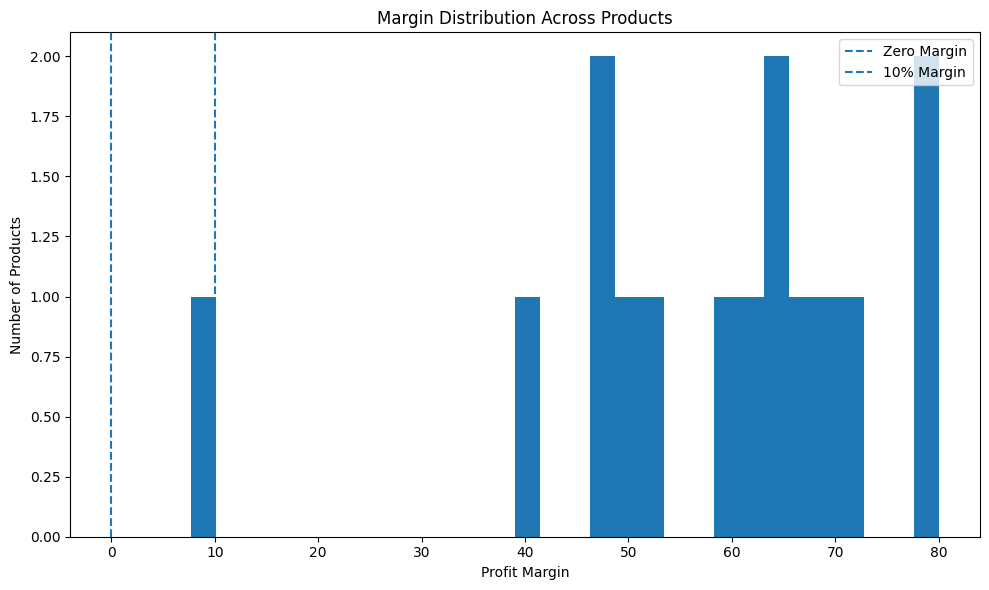

In [ ]:
# Margin Distribution across Products

plt.figure(figsize=(10,6))

plt.hist(product_df['Gross_Margin_%'], bins=30)

plt.axvline(0, linestyle='--', label='Zero Margin')
plt.axvline(10, linestyle='--', label='10% Margin')

plt.title("Margin Distribution Across Products")
plt.xlabel("Profit Margin")
plt.ylabel("Number of Products")
plt.legend()

plt.tight_layout()
plt.show()

Most products have a profit margin between **40% - 70%**, indicating generally strong profitability. Very few products fall near the **low margin range (below 20%)**, suggesting limited underperforming items. Around **80% of the products lie above the 40% margin level**, showing that the majority of the portfolio is highly profitable. Overall, the distribution reflects a **healthy and high-margin business with minimal low-performing products**.

In [ ]:
# Extract Year for yearly aggregation
df['Year'] = df['Order Date'].dt.to_period('Y')

# Group by Year and calculate total sales, cost, and gross margin
yearly_margin = df.groupby('Year').agg({
    'Sales': 'sum',
    'Cost': 'sum'
}).reset_index()

yearly_margin = add_margin(yearly_margin)

# Convert 'Year' back to a datetime object for easier filtering and plotting
yearly_margin['Year'] = yearly_margin['Year'].dt.to_timestamp()

print("\nYearly Margin:\n")
display(yearly_margin)

print(f"\nMinimum Order Year: {yearly_margin['Year'].min().strftime('%Y')}")
print(f"Maximum Order Year: {yearly_margin['Year'].max().strftime('%Y')}")


Yearly Margin:



,Year,Sales,Cost,Gross_Margin_%
0,2024-01-01,57956.20,19804.77,65.828039
1,2025-01-01,83827.43,28536.06,65.958565



Minimum Order Year: 2024
Maximum Order Year: 2025


Sales increased by **25,871.23** (57,956.20 → 83,827.43), and cost increased by **8,731.29.**
Gross margin slightly improved from **65.83% to 65.96%**(+0.13%), showing stable and efficient growth.

In [ ]:
df['YearMonth'] = df['Order Date'].dt.to_period('M')

monthly_margin = df.groupby('YearMonth').agg({
    'Sales': 'sum',
    'Cost': 'sum'
}).reset_index()

monthly_margin = add_margin(monthly_margin)

monthly_margin['YearMonth'] = monthly_margin['YearMonth'].dt.to_timestamp()

# Filter for 2024 and 2025 as seen in the yearly analysis
monthly_margin_filtered = monthly_margin[
    (monthly_margin['YearMonth'].dt.year == 2024) |
    (monthly_margin['YearMonth'].dt.year == 2025)
]

print("\nMonthly Margin (2024-2025):\n")
display(monthly_margin_filtered.head())


Monthly Margin (2024-2025):



,YearMonth,Sales,Cost,Gross_Margin_%
0,2024-01-01,2093.90,727.76,65.243803
1,2024-02-01,1379.87,471.28,65.846058
2,2024-03-01,4138.90,1467.74,64.537921
3,2024-04-01,3988.22,1375.41,65.513186
4,2024-05-01,3951.52,1336.08,66.188201


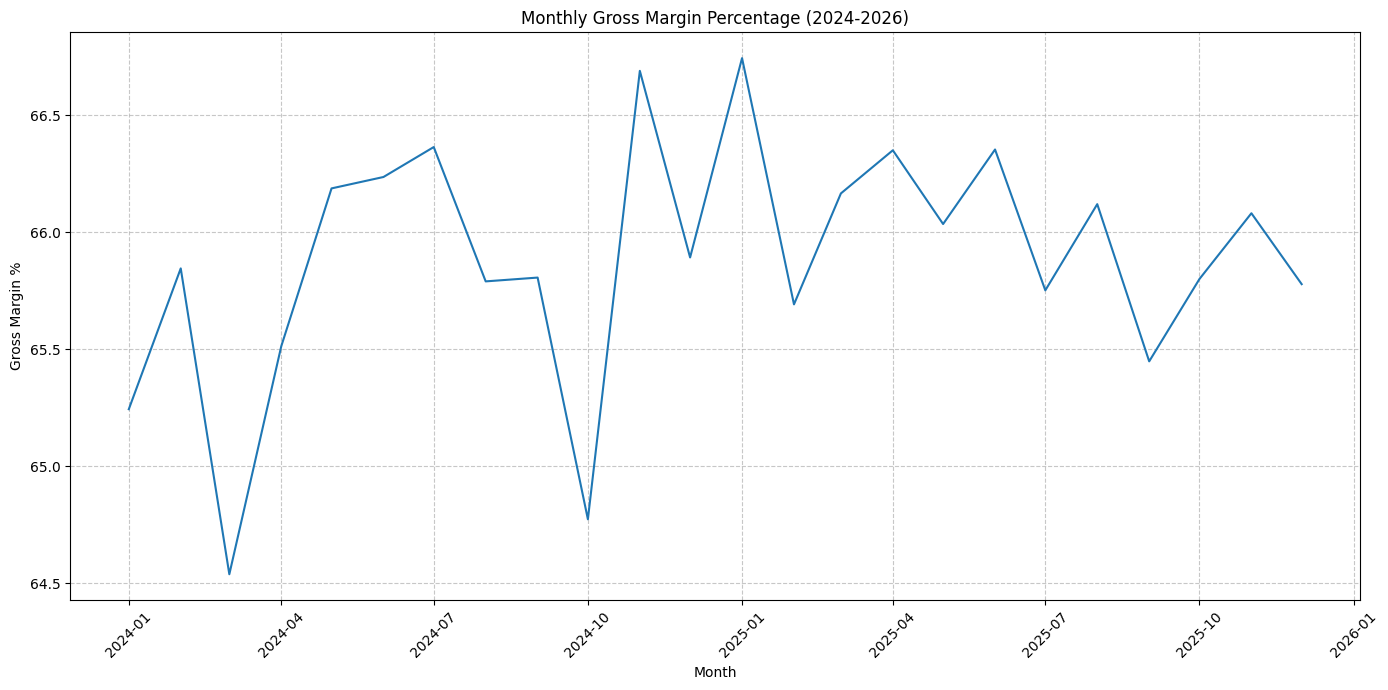

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(x='YearMonth', y='Gross_Margin_%', data=monthly_margin_filtered)
plt.title('Monthly Gross Margin Percentage (2024-2026)')
plt.xlabel('Month')
plt.ylabel('Gross Margin %')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Gross margin remains stable around **65%–66.8%**, indicating consistent profitability and strong cost control.
A slight dip around late 2024 suggests temporary cost or pricing pressure, but overall fluctuations are minimal.

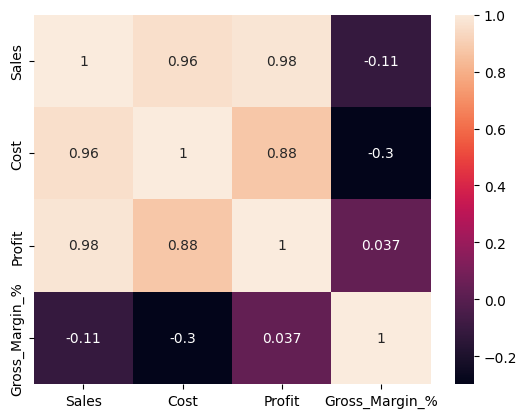

In [ ]:
# Correlation Heatmap of Sales, Profit, Cost & Margin

sns.heatmap(df[['Sales','Cost','Profit','Gross_Margin_%']].corr(), annot=True)
plt.show()

**Sales, Cost, and Profit** are almost perfectly correlated **(\~0.98–1)**, meaning they move together very strongly — higher sales directly lead to higher cost and profit.
This indicates a **consistent business model**, where cost scales proportionally with sales.
**Gross Margin**  has only a **moderate correlation (\~0.3–0.4)** with other variables, showing it behaves more independently.
Overall, revenue growth is strong, but **profitability efficiency (margin)** is not tightly linked to sales, suggesting scope for margin optimization.

## **Overall Conclusion**

Nassau Candy Distributor exhibits strong overall profitability, heavily driven by its efficient **Chocolate** division. While financially stable, the business faces significant dependency risk on a few high-performing products. Strategic opportunities lie in optimizing low-margin items, addressing underperforming divisions, and carefully considering product discontinuation to enhance long-term stability and growth.

### **Key Insights**

*   **High-profit / high-margin products:** Wonka Bar variants like 'Scrumdiddlyumptious' and 'Triple Dazzle Caramel', along with 'Everlasting Gobstopper', demonstrate strong profitability and high margins.
*   High Dependency Risk: Approximately **77%** of both revenue and profit are concentrated in a few Wonka Bar variants, posing a significant dependency risk.
*   Margin Issues: **'Kazookles'** shows extremely low margins despite moderate sales, indicating potential pricing or cost inefficiencies.
*   Underperforming Products/Divisions: The **'Other'** division exhibits lower and more volatile margins. Products like **'Fun Dip'**, **'Nerds'**, and **'SweeTARTS'** consistently show low sales, profit, and margins.

### **Recommendations**

*   **Fortify Core:** Continue investment and innovation in the high-performing **Chocolate division** and **key Wonka Bar** variants.
*   **Optimize Weak Products:** Prioritize review of **'Kazookles'** for repricing, cost renegotiation, or discontinuation. Improve the **'Other'** division's efficiency.
*   **Diversify & Streamline:** Consider phasing out low-impact, low-profit products (**'Fun Dip', 'Nerds', 'SweeTARTS'**) and explore growth potential in regions like 'Gulf' to diversify revenue streams.